In [1]:
import nltk
nltk.download('vader_lexicon')
import pandas as pd
import os
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Creating directory structure
for folder in ['data', 'visuals']:
    if not os.path.exists(folder):
        os.makedirs(folder)
        
# 1. Setting up VADER
analyzer = SentimentIntensityAnalyzer()

# 2. Simulating Reddit Data (What the API would return)
reddit_comments = [
    "The battery life on the Vision Pro 2 is a joke. Only 2 hours?!",
    "Absolutely stunned by the new micro-OLED display. Best VR ever.",
    "Too expensive. Apple is out of touch with reality.",
    "The hand tracking is finally perfect. Massive improvement.",
    "Pass-through is still grainier than I expected for $3500."
]

# 3. Processing Sentiment
results = []
for comment in reddit_comments:
    score = analyzer.polarity_scores(comment)
    results.append({
        'text': comment,
        'sentiment_score': score['compound'],
        'label': 'Positive' if score['compound'] > 0.05 else ('Negative' if score['compound'] < -0.05 else 'Neutral')
    })

df = pd.DataFrame(results)
df.to_csv('data/apple_sentiment_results.csv', index=False)
print(df)

                                                text  sentiment_score  \
0  The battery life on the Vision Pro 2 is a joke...           0.5411   
1  Absolutely stunned by the new micro-OLED displ...           0.5434   
2  Too expensive. Apple is out of touch with real...           0.0000   
3  The hand tracking is finally perfect. Massive ...           0.8720   
4  Pass-through is still grainier than I expected...           0.0000   

      label  
0  Positive  
1  Positive  
2   Neutral  
3  Positive  
4   Neutral  


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [2]:
from sklearn.feature_extraction.text import CountVectorizer

# Simple way to get Bi-grams
cv = CountVectorizer(ngram_range=(2, 2), stop_words='english')
bigrams = cv.fit_transform(reddit_comments)

# Summing the counts of each bigram
sum_words = bigrams.sum(axis=0) 

# Getting the bigram names (features)
words_freq = [(word, sum_words[0, idx]) for word, idx in cv.vocabulary_.items()]

# Sorting by frequency
words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)

# Creating a clean DataFrame
bigram_df = pd.DataFrame(words_freq, columns=['Bigram', 'Frequency'])
bigram_df.to_csv('data/apple_bigram_analysis.csv', index=False)
print(bigram_df.head(5))

         Bigram  Frequency
0  battery life          1
1   life vision          1
2    vision pro          1
3      pro joke          1
4    joke hours          1


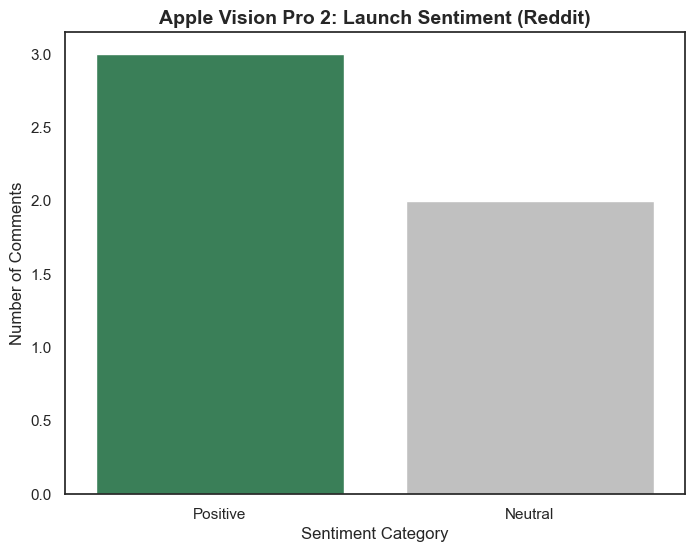

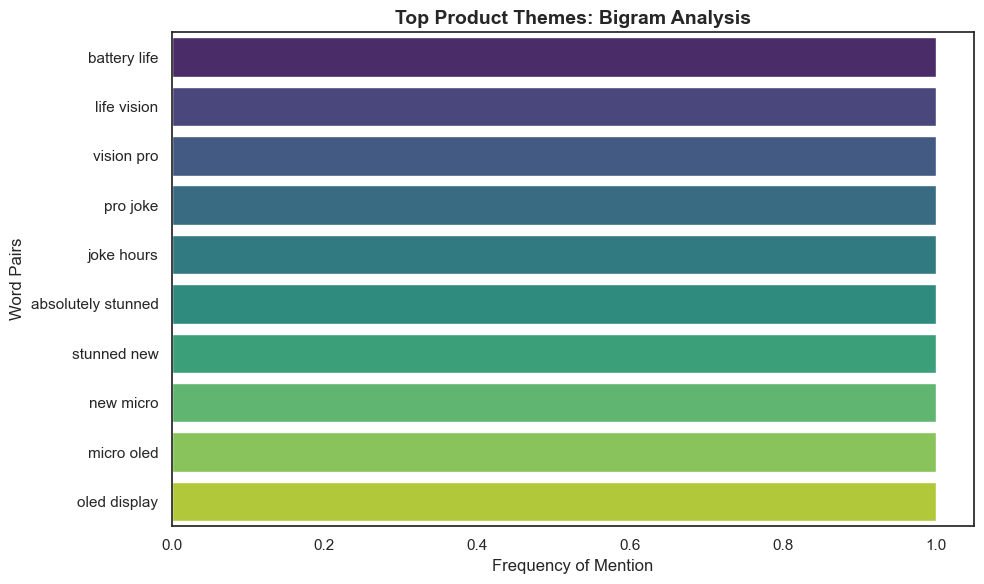

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setting professional theme
sns.set_theme(style="white")

# --- 1. Sentiment Distribution Plot ---
plt.figure(figsize=(8, 6))
# Counting the labels from results dataframe 'df'
sentiment_counts = df['label'].value_counts()

sns.barplot(
    x=sentiment_counts.index, 
    y=sentiment_counts.values, 
    hue=sentiment_counts.index, 
    palette={'Positive': 'seagreen', 'Negative': 'crimson', 'Neutral': 'silver'},
    legend=False
)
plt.title('Apple Vision Pro 2: Launch Sentiment (Reddit)', fontsize=14, fontweight='bold')
plt.ylabel('Number of Comments')
plt.xlabel('Sentiment Category')
plt.savefig('visuals/sentiment_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# --- 2. Bigram Frequency Plot ---
# Using the 'bigram_df' we created in the previous step
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Frequency', 
    y='Bigram', 
    data=bigram_df.head(10), # Showing top 10 word pairs
    hue='Bigram',             
    palette='viridis', 
    legend=False
)
plt.title('Top Product Themes: Bigram Analysis', fontsize=14, fontweight='bold')
plt.xlabel('Frequency of Mention')
plt.ylabel('Word Pairs')
plt.tight_layout()
plt.savefig('visuals/product_themes_bigrams.png', dpi=300, bbox_inches='tight')
plt.show()

with open("visuals/nlp_summary.txt", "w") as f:
    f.write("Apple Vision Pro 2 Sentiment Analysis Summary\n")
    f.write("============================================\n")
    f.write(f"Total Comments Analyzed: {len(df)}\n")
    f.write(f"Sentiment Breakdown:\n{sentiment_counts.to_string()}\n")